In [2]:
from pathlib import Path
import gc
import json
import os
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.inspection import permutation_importance

PROJECT_DIR = Path(r"D:\Sami Data Set")

TEST_DIR = PROJECT_DIR / "data" / "splits" / "test"
DOCUMENTATION_DIR = PROJECT_DIR / "documentation"
TABLES_DIR = PROJECT_DIR / "outputs" / "tables"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
PREDICTIONS_DIR = PROJECT_DIR / "outputs" / "predictions"
MODELS_DIR = PROJECT_DIR / "models"
INTERIM_DIR = PROJECT_DIR / "data" / "interim"
POWERBI_DIR = PROJECT_DIR / "powerbi"

for directory in [
    DOCUMENTATION_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
    INTERIM_DIR,
    POWERBI_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42

CPU_COUNT = os.cpu_count() or 2
N_JOBS = max(1, CPU_COUNT - 1)

final_model_path = (
    MODELS_DIR / "final_model.joblib"
)

evaluation_json_path = (
    DOCUMENTATION_DIR
    / "final_model_evaluation.json"
)

final_results_path = (
    TABLES_DIR
    / "final_model_test_results.csv"
)

attack_results_path = (
    TABLES_DIR
    / "final_test_results_by_attack_label.csv"
)

file_results_path = (
    TABLES_DIR
    / "final_test_results_by_file.csv"
)

misclassification_path = (
    PREDICTIONS_DIR
    / "final_test_misclassifications.parquet"
)

required_files = {
    "Final model": final_model_path,
    "Evaluation documentation": evaluation_json_path,
    "Final results": final_results_path,
    "Attack results": attack_results_path,
    "File results": file_results_path
}

for name, path in required_files.items():
    print(
        name,
        ":",
        "FOUND" if path.exists() else "MISSING",
        "|",
        path
    )

missing_files = [
    name
    for name, path in required_files.items()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        f"Missing required files: {missing_files}"
    )

test_files = sorted(
    TEST_DIR.glob("*_test.parquet")
)

print("\nTest files found:", len(test_files))
print("CPU cores available:", CPU_COUNT)
print("CPU cores to use:", N_JOBS)
print("Setup completed.")


Final model : FOUND | D:\Sami Data Set\models\final_model.joblib
Evaluation documentation : FOUND | D:\Sami Data Set\documentation\final_model_evaluation.json
Final results : FOUND | D:\Sami Data Set\outputs\tables\final_model_test_results.csv
Attack results : FOUND | D:\Sami Data Set\outputs\tables\final_test_results_by_attack_label.csv
File results : FOUND | D:\Sami Data Set\outputs\tables\final_test_results_by_file.csv

Test files found: 10
CPU cores available: 2
CPU cores to use: 1
Setup completed.


In [3]:
final_model = joblib.load(
    final_model_path
)

with open(
    evaluation_json_path,
    "r",
    encoding="utf-8"
) as evaluation_file:
    evaluation_information = json.load(
        evaluation_file
    )

final_algorithm = evaluation_information[
    "final_algorithm"
]

selected_features = evaluation_information[
    "selected_features"
]

final_results = pd.read_csv(
    final_results_path
)

attack_results = pd.read_csv(
    attack_results_path
)

file_results = pd.read_csv(
    file_results_path
)

print("Final algorithm:", final_algorithm)
print("Selected features:", len(selected_features))
print(
    "Training records:",
    f"{evaluation_information['training_records']:,}"
)
print(
    "Test records:",
    f"{evaluation_information['test_records']:,}"
)

display(final_results)

Final algorithm: XGBoost
Selected features: 20
Training records: 5,327,625
Test records: 1,331,907


,model,records_evaluated,number_of_features,classification_threshold,accuracy,malicious_precision,malicious_recall,malicious_f1,roc_auc,average_precision,false_positive_rate,false_negative_rate,true_negatives,false_positives,false_negatives,true_positives,training_seconds,test_prediction_seconds
0,XGBoost,1331907,20,0.5,0.980038,0.979185,0.919633,0.948475,0.988208,0.974639,0.004881,0.080367,1060600,5202,21386,244719,392.815,19.752


In [4]:
malicious_attack_results = attack_results[
    attack_results["actual_malicious"] > 0
].copy()

malicious_attack_results = (
    malicious_attack_results
    .sort_values(
        [
            "attack_detection_rate",
            "total_records"
        ],
        ascending=[
            True,
            False
        ]
    )
)

display(
    malicious_attack_results[
        [
            "original_attack_label",
            "total_records",
            "true_positives",
            "false_negatives",
            "attack_detection_rate"
        ]
    ]
)

print("\nLowest attack-detection rates:")

display(
    malicious_attack_results[
        [
            "original_attack_label",
            "total_records",
            "attack_detection_rate",
            "false_negatives"
        ]
    ].head(10)
)



,original_attack_label,total_records,true_positives,false_negatives,attack_detection_rate
4,Infilteration,23697,2536,21161,0.107018
9,Brute Force -Web,115,69,46,0.600000
11,SQL Injection,20,19,1,0.950000
10,Brute Force -XSS,41,40,1,0.975610
7,DoS attacks-Slowloris,1980,1967,13,0.993434
3,Bot,28907,28746,161,0.994430
6,DoS attacks-GoldenEye,8283,8282,1,0.999879
0,DDoS attacks-LOIC-HTTP,115073,115071,2,0.999983
1,DDOS attack-HOIC,39772,39772,0,1.000000
2,DoS attacks-Hulk,29045,29045,0,1.000000



Lowest attack-detection rates:


,original_attack_label,total_records,attack_detection_rate,false_negatives
4,Infilteration,23697,0.107018,21161
9,Brute Force -Web,115,0.600000,46
11,SQL Injection,20,0.950000,1
10,Brute Force -XSS,41,0.975610,1
7,DoS attacks-Slowloris,1980,0.993434,13
3,Bot,28907,0.994430,161
6,DoS attacks-GoldenEye,8283,0.999879,1
0,DDoS attacks-LOIC-HTTP,115073,0.999983,2
1,DDOS attack-HOIC,39772,1.000000,0
2,DoS attacks-Hulk,29045,1.000000,0


In [5]:
malicious_attack_results = attack_results[
    attack_results["actual_malicious"] > 0
].copy()

malicious_attack_results = (
    malicious_attack_results
    .sort_values(
        [
            "attack_detection_rate",
            "total_records"
        ],
        ascending=[
            True,
            False
        ]
    )
)

display(
    malicious_attack_results[
        [
            "original_attack_label",
            "total_records",
            "true_positives",
            "false_negatives",
            "attack_detection_rate"
        ]
    ]
)

print("\nLowest attack-detection rates:")

display(
    malicious_attack_results[
        [
            "original_attack_label",
            "total_records",
            "attack_detection_rate",
            "false_negatives"
        ]
    ].head(10)
)

,original_attack_label,total_records,true_positives,false_negatives,attack_detection_rate
4,Infilteration,23697,2536,21161,0.107018
9,Brute Force -Web,115,69,46,0.600000
11,SQL Injection,20,19,1,0.950000
10,Brute Force -XSS,41,40,1,0.975610
7,DoS attacks-Slowloris,1980,1967,13,0.993434
3,Bot,28907,28746,161,0.994430
6,DoS attacks-GoldenEye,8283,8282,1,0.999879
0,DDoS attacks-LOIC-HTTP,115073,115071,2,0.999983
1,DDOS attack-HOIC,39772,39772,0,1.000000
2,DoS attacks-Hulk,29045,29045,0,1.000000



Lowest attack-detection rates:


,original_attack_label,total_records,attack_detection_rate,false_negatives
4,Infilteration,23697,0.107018,21161
9,Brute Force -Web,115,0.600000,46
11,SQL Injection,20,0.950000,1
10,Brute Force -XSS,41,0.975610,1
7,DoS attacks-Slowloris,1980,0.993434,13
3,Bot,28907,0.994430,161
6,DoS attacks-GoldenEye,8283,0.999879,1
0,DDoS attacks-LOIC-HTTP,115073,0.999983,2
1,DDOS attack-HOIC,39772,1.000000,0
2,DoS attacks-Hulk,29045,1.000000,0


In [6]:
if not hasattr(
    final_model,
    "feature_importances_"
):
    raise AttributeError(
        "The final model does not provide "
        "native feature importance."
    )

native_importance = pd.DataFrame({
    "feature": selected_features,
    "native_importance":
        final_model.feature_importances_
})

native_importance = (
    native_importance
    .sort_values(
        "native_importance",
        ascending=False
    )
    .reset_index(drop=True)
)

native_importance[
    "native_rank"
] = range(
    1,
    len(native_importance) + 1
)

display(native_importance)

native_importance.to_csv(
    TABLES_DIR
    / "final_model_native_feature_importance.csv",
    index=False
)

,feature,native_importance,native_rank
0,Fwd Seg Size Min,0.160091,1
1,Bwd IAT Min,0.154985,2
2,RST Flag Count,0.105046,3
3,Flow Duration,0.095989,4
4,Fwd IAT Std,0.071886,5
5,Init Fwd Win Bytes,0.067227,6
6,Bwd Packet Length Std,0.059036,7
7,Packet Length Max,0.053594,8
8,Init Bwd Win Bytes,0.052863,9
9,Packet Length Mean,0.034174,10


In [7]:
ROWS_PER_CLASS_PER_FILE = 2_500

explanation_parts = []

required_columns = (
    selected_features
    + [
        "binary_label",
        "original_attack_label",
        "source_file_id",
        "source_row_id"
    ]
)

for file_number, file_path in enumerate(
    test_files,
    start=1
):
    print(
        f"[{file_number}/{len(test_files)}] "
        f"Sampling {file_path.name}",
        flush=True
    )

    df = pd.read_parquet(
        file_path,
        columns=required_columns
    )

    for class_value in [0, 1]:
        class_data = df[
            df["binary_label"] == class_value
        ]

        sample_size = min(
            ROWS_PER_CLASS_PER_FILE,
            len(class_data)
        )

        if sample_size > 0:
            sampled_data = class_data.sample(
                n=sample_size,
                random_state=(
                    RANDOM_SEED
                    + file_number * 10
                    + class_value
                )
            )

            explanation_parts.append(
                sampled_data
            )

    del df
    gc.collect()

explanation_sample = pd.concat(
    explanation_parts,
    ignore_index=True
)

X_explanation = (
    explanation_sample[selected_features]
    .astype("float32")
)

explanation_predictions = (
    final_model.predict(
        X_explanation
    ).astype("int8")
)

explanation_probabilities = (
    final_model.predict_proba(
        X_explanation
    )[:, 1]
)

explanation_sample[
    "predicted_label"
] = explanation_predictions

explanation_sample[
    "malicious_probability"
] = explanation_probabilities

explanation_sample[
    "prediction_result"
] = np.select(
    [
        (
            explanation_sample["binary_label"] == 0
        )
        & (
            explanation_sample["predicted_label"] == 0
        ),
        (
            explanation_sample["binary_label"] == 0
        )
        & (
            explanation_sample["predicted_label"] == 1
        ),
        (
            explanation_sample["binary_label"] == 1
        )
        & (
            explanation_sample["predicted_label"] == 0
        ),
        (
            explanation_sample["binary_label"] == 1
        )
        & (
            explanation_sample["predicted_label"] == 1
        )
    ],
    [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    default="Unknown"
)

explanation_sample_path = (
    INTERIM_DIR
    / "final_model_explanation_sample.parquet"
)

explanation_sample.to_parquet(
    explanation_sample_path,
    engine="pyarrow",
    compression="snappy",
    index=False
)

print(
    "\nExplanation sample records:",
    f"{len(explanation_sample):,}"
)

display(
    explanation_sample[
        "prediction_result"
    ].value_counts()
)

print(
    "Explanation sample saved to:",
    explanation_sample_path
)

[1/10] Sampling Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter_test.parquet
[2/10] Sampling Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter_test.parquet
[3/10] Sampling DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter_test.parquet
[4/10] Sampling DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter_test.parquet
[5/10] Sampling DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter_test.parquet
[6/10] Sampling DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter_test.parquet
[7/10] Sampling Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter_test.parquet
[8/10] Sampling Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter_test.parquet
[9/10] Sampling Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter_test.parquet
[10/10] Sampling Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter_test.parquet

Explanation sample records: 45,176


prediction_result
True Negative     24787
True Positive     15600
False Negative     4576
False Positive      213
Name: count, dtype: int64

Explanation sample saved to: D:\Sami Data Set\data\interim\final_model_explanation_sample.parquet


In [8]:
PERMUTATION_SAMPLE_SIZE = min(
    20_000,
    len(explanation_sample)
)

permutation_sample = (
    explanation_sample
    .sample(
        n=PERMUTATION_SAMPLE_SIZE,
        random_state=RANDOM_SEED
    )
    .reset_index(drop=True)
)

X_permutation = (
    permutation_sample[selected_features]
    .astype("float32")
)

y_permutation = (
    permutation_sample["binary_label"]
    .astype("int8")
)

print(
    "Calculating permutation importance "
    f"using {PERMUTATION_SAMPLE_SIZE:,} records...",
    flush=True
)

permutation_start = time.time()

permutation_result = permutation_importance(
    estimator=final_model,
    X=X_permutation,
    y=y_permutation,
    scoring="f1",
    n_repeats=3,
    random_state=RANDOM_SEED,
    n_jobs=N_JOBS
)

permutation_seconds = (
    time.time() - permutation_start
)

permutation_importance_table = pd.DataFrame({
    "feature": selected_features,
    "permutation_importance_mean":
        permutation_result.importances_mean,
    "permutation_importance_std":
        permutation_result.importances_std
})

permutation_importance_table = (
    permutation_importance_table
    .sort_values(
        "permutation_importance_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

permutation_importance_table[
    "permutation_rank"
] = range(
    1,
    len(permutation_importance_table) + 1
)

display(permutation_importance_table)

print(
    "Permutation analysis time:",
    round(permutation_seconds, 2),
    "seconds"
)

permutation_importance_table.to_csv(
    TABLES_DIR
    / "final_model_permutation_importance.csv",
    index=False
)

Calculating permutation importance using 20,000 records...


,feature,permutation_importance_mean,permutation_importance_std,permutation_rank
0,Fwd Seg Size Min,0.090589,0.004052,1
1,Init Fwd Win Bytes,0.071265,0.000465,2
2,RST Flag Count,0.010369,0.000506,3
3,Fwd Packet Length Max,0.006752,0.000152,4
4,Init Bwd Win Bytes,0.002863,0.000369,5
5,Bwd IAT Min,0.002431,0.000068,6
6,Fwd IAT Std,0.001983,0.000130,7
7,Flow Duration,0.001858,0.000402,8
8,Bwd Packets Length Total,0.001424,0.000243,9
9,Flow IAT Max,0.001187,0.000567,10


Permutation analysis time: 11.88 seconds


In [9]:
SHAP_SAMPLE_SIZE = min(
    2_000,
    len(explanation_sample)
)

example_parts = []

for result_type in [
    "True Positive",
    "False Positive",
    "False Negative"
]:
    available_examples = explanation_sample[
        explanation_sample["prediction_result"]
        == result_type
    ]

    if not available_examples.empty:
        example_parts.append(
            available_examples.sample(
                n=1,
                random_state=RANDOM_SEED
            )
        )

if example_parts:
    required_examples = pd.concat(
        example_parts
    )

    remaining_data = explanation_sample.drop(
        index=required_examples.index
    )

    remaining_size = (
        SHAP_SAMPLE_SIZE
        - len(required_examples)
    )

    random_explanation_rows = (
        remaining_data.sample(
            n=remaining_size,
            random_state=RANDOM_SEED
        )
    )

    shap_sample = pd.concat(
        [
            random_explanation_rows,
            required_examples
        ],
        ignore_index=True
    )

else:
    shap_sample = explanation_sample.sample(
        n=SHAP_SAMPLE_SIZE,
        random_state=RANDOM_SEED
    ).reset_index(drop=True)

X_shap = (
    shap_sample[selected_features]
    .astype("float32")
)

print(
    "SHAP sample records:",
    f"{len(X_shap):,}"
)

display(
    shap_sample[
        "prediction_result"
    ].value_counts()
)



SHAP sample records: 2,000


prediction_result
True Negative     1079
True Positive      737
False Negative     174
False Positive      10
Name: count, dtype: int64

In [10]:
SHAP_COMPLETED = False

try:
    print(
        "Calculating SHAP values...",
        flush=True
    )

    shap_start = time.time()

    shap_explainer = shap.TreeExplainer(
        final_model
    )

    raw_shap_values = (
        shap_explainer.shap_values(
            X_shap
        )
    )

    if isinstance(
        raw_shap_values,
        list
    ):
        shap_values_positive = (
            raw_shap_values[1]
        )

    else:
        raw_shap_array = np.asarray(
            raw_shap_values
        )

        if raw_shap_array.ndim == 3:
            shap_values_positive = (
                raw_shap_array[:, :, 1]
            )
        else:
            shap_values_positive = (
                raw_shap_array
            )

    if shap_values_positive.shape != (
        len(X_shap),
        len(selected_features)
    ):
        raise ValueError(
            "Unexpected SHAP array shape: "
            f"{shap_values_positive.shape}"
        )

    shap_seconds = (
        time.time() - shap_start
    )

    shap_importance = pd.DataFrame({
        "feature": selected_features,
        "mean_absolute_shap":
            np.abs(
                shap_values_positive
            ).mean(axis=0)
    })

    shap_importance = (
        shap_importance
        .sort_values(
            "mean_absolute_shap",
            ascending=False
        )
        .reset_index(drop=True)
    )

    shap_importance[
        "shap_rank"
    ] = range(
        1,
        len(shap_importance) + 1
    )

    display(shap_importance)

    shap_importance.to_csv(
        TABLES_DIR
        / "final_model_shap_importance.csv",
        index=False
    )

    np.savez_compressed(
        INTERIM_DIR
        / "final_model_shap_values.npz",
        shap_values=
            shap_values_positive,
        feature_names=np.array(
            selected_features,
            dtype=object
        )
    )

    SHAP_COMPLETED = True

    print(
        "SHAP analysis completed in:",
        round(shap_seconds, 2),
        "seconds"
    )

except Exception as error:
    print(
        "SHAP calculation could not be completed:"
    )
    print(type(error).__name__, ":", error)

Calculating SHAP values...


,feature,mean_absolute_shap,shap_rank
0,Fwd Seg Size Min,1.012419,1
1,Init Fwd Win Bytes,0.881910,2
2,RST Flag Count,0.805806,3
3,Bwd IAT Min,0.523099,4
4,Fwd Packet Length Max,0.503282,5
5,Init Bwd Win Bytes,0.398537,6
6,Fwd IAT Std,0.337884,7
7,Flow Duration,0.292877,8
8,Bwd Packet Length Std,0.244808,9
9,Fwd Packet Length Std,0.236380,10


SHAP analysis completed in: 6.32 seconds


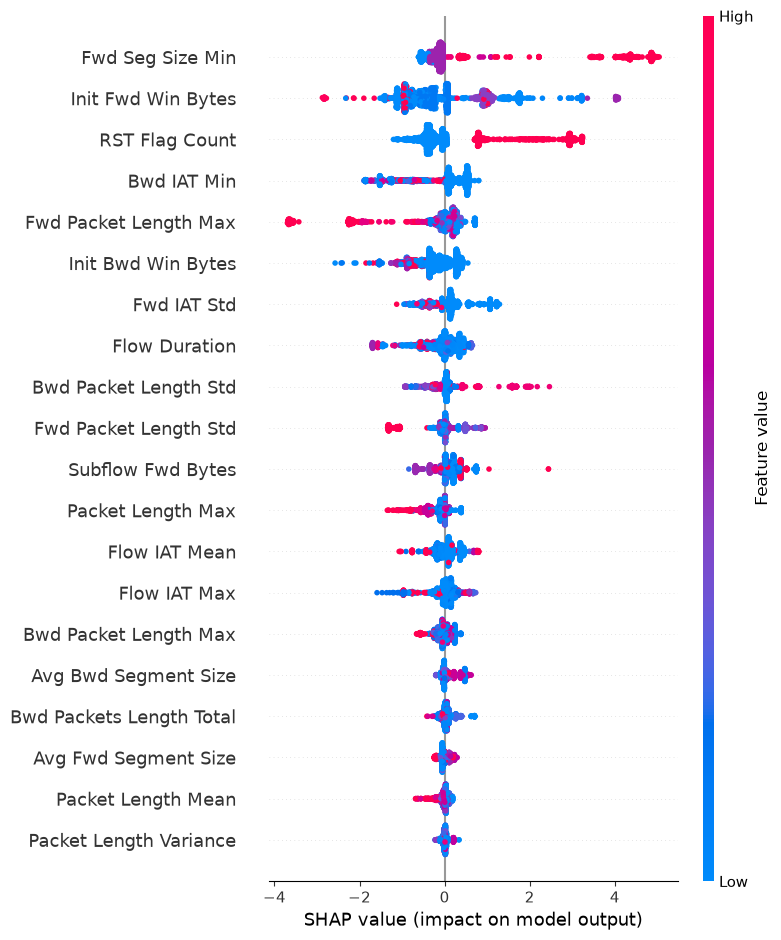

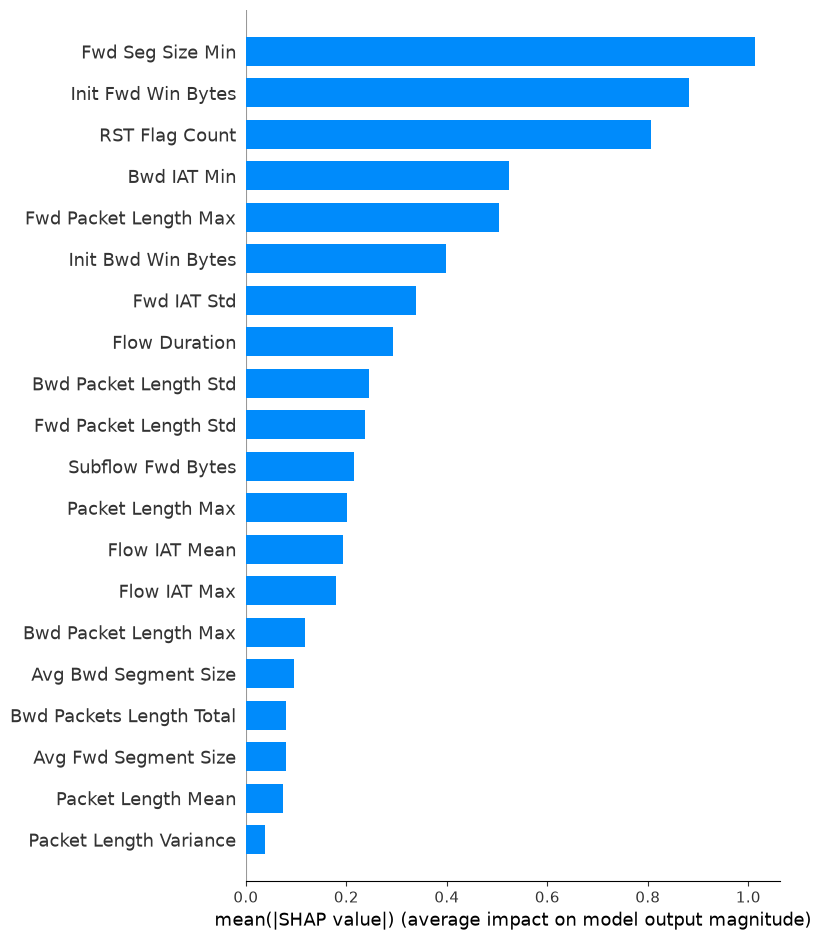

SHAP figures saved successfully.


In [13]:
if SHAP_COMPLETED:
    shap.summary_plot(
        shap_values_positive,
        X_shap,
        max_display=len(selected_features),
        show=False
    )

    plt.tight_layout()

    shap_summary_path = (
        FIGURES_DIR
        / "final_model_shap_summary.png"
    )

    plt.savefig(
        shap_summary_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    shap.summary_plot(
        shap_values_positive,
        X_shap,
        plot_type="bar",
        max_display=len(selected_features),
        show=False
    )

    plt.tight_layout()

    shap_bar_path = (
        FIGURES_DIR
        / "final_model_shap_importance_bar.png"
    )

    plt.savefig(
        shap_bar_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print(
        "SHAP figures saved successfully."
    )

else:
    print(
        "SHAP figures skipped because "
        "SHAP calculation was not completed."
    )

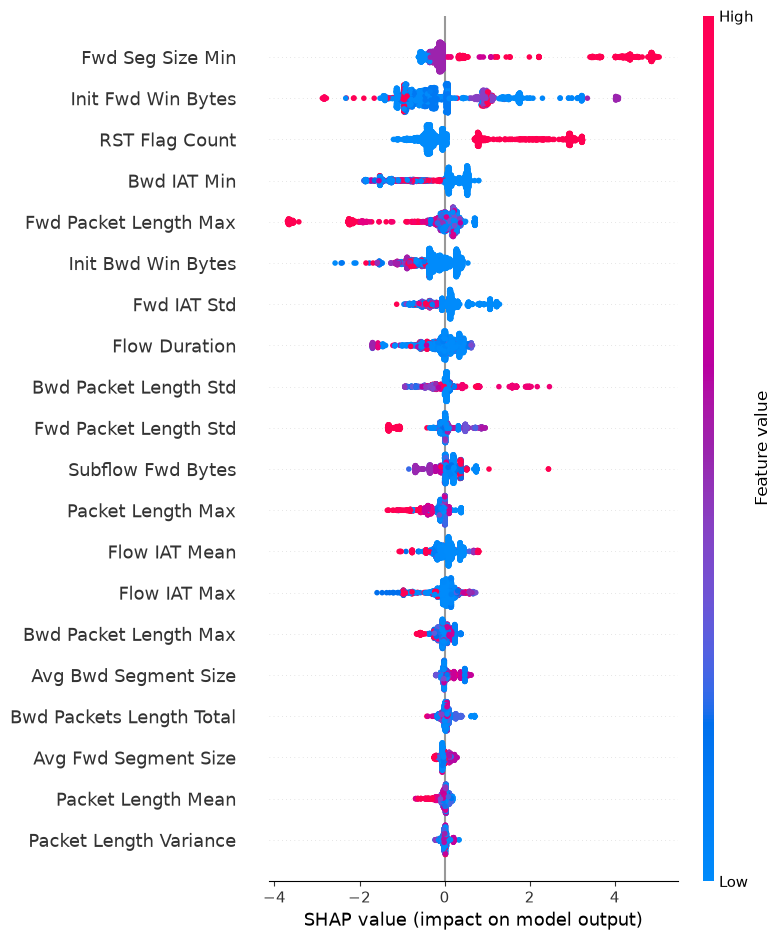

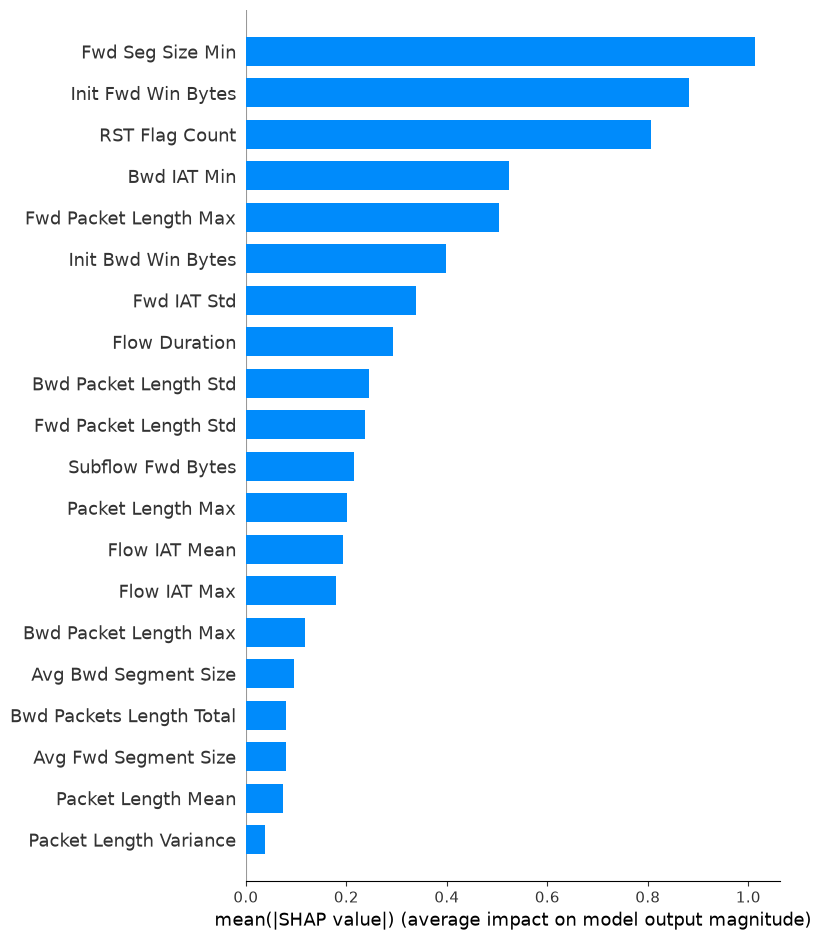

SHAP figures saved successfully.


In [14]:
if SHAP_COMPLETED:
    shap.summary_plot(
        shap_values_positive,
        X_shap,
        max_display=len(selected_features),
        show=False
    )

    plt.tight_layout()

    shap_summary_path = (
        FIGURES_DIR
        / "final_model_shap_summary.png"
    )

    plt.savefig(
        shap_summary_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    shap.summary_plot(
        shap_values_positive,
        X_shap,
        plot_type="bar",
        max_display=len(selected_features),
        show=False
    )

    plt.tight_layout()

    shap_bar_path = (
        FIGURES_DIR
        / "final_model_shap_importance_bar.png"
    )

    plt.savefig(
        shap_bar_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print(
        "SHAP figures saved successfully."
    )

else:
    print(
        "SHAP figures skipped because "
        "SHAP calculation was not completed."
    )

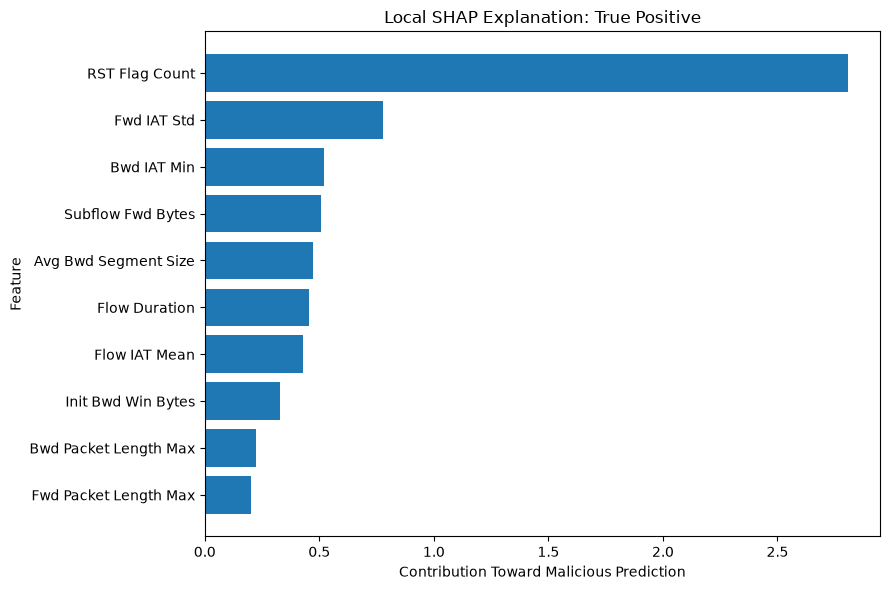

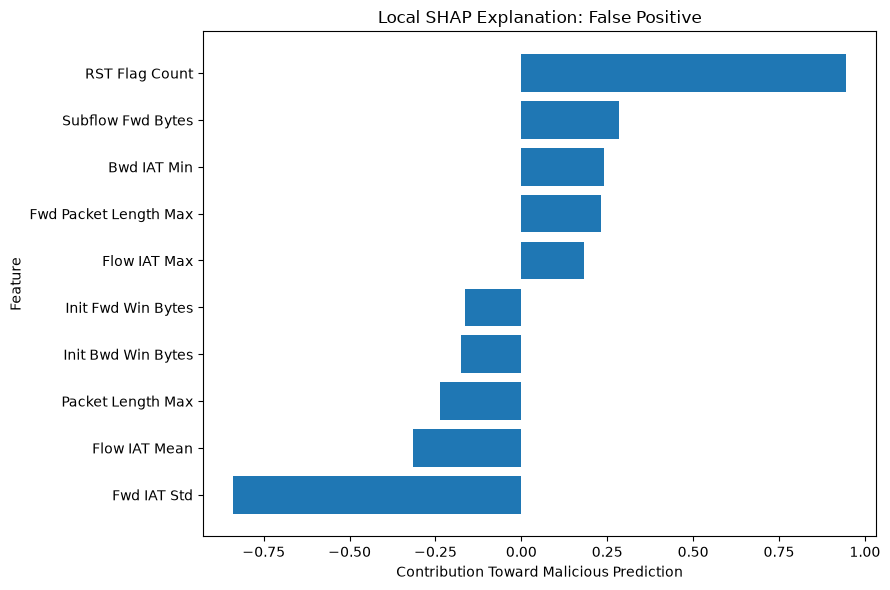

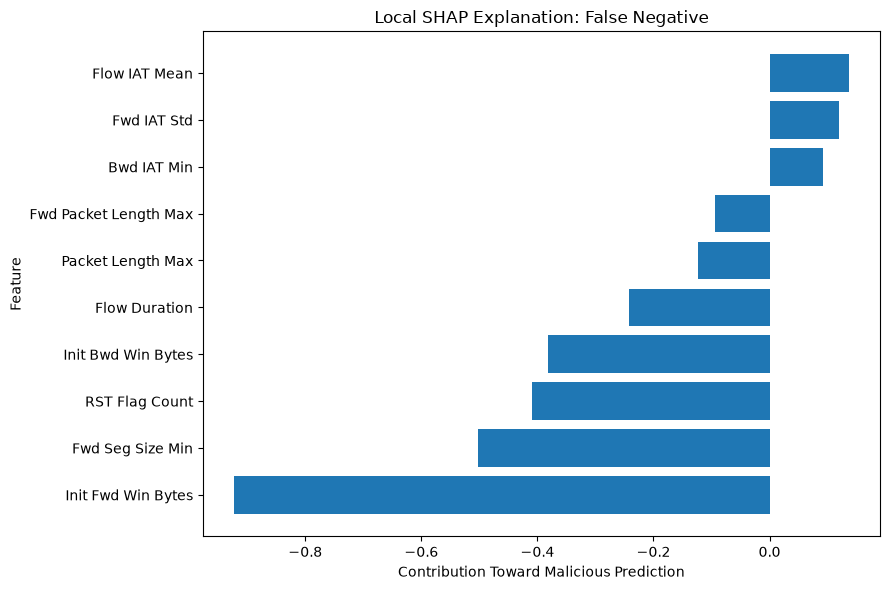

,prediction_result,feature,feature_value,shap_contribution,absolute_shap_contribution,actual_label,predicted_label,malicious_probability,original_attack_label
0,True Positive,RST Flag Count,1.000000e+00,2.807172,2.807172,1,1,0.999383,Bot
1,True Positive,Fwd IAT Std,5.628570e+02,0.779974,0.779974,1,1,0.999383,Bot
2,True Positive,Bwd IAT Min,7.200000e+01,0.521805,0.521805,1,1,0.999383,Bot
3,True Positive,Subflow Fwd Bytes,3.260000e+02,0.505441,0.505441,1,1,0.999383,Bot
4,True Positive,Avg Bwd Segment Size,3.225000e+01,0.472014,0.472014,1,1,0.999383,Bot
5,True Positive,Flow Duration,1.090700e+04,0.456167,0.456167,1,1,0.999383,Bot
6,True Positive,Flow IAT Mean,1.817833e+03,0.429475,0.429475,1,1,0.999383,Bot
7,True Positive,Init Bwd Win Bytes,2.190000e+02,0.329782,0.329782,1,1,0.999383,Bot
8,True Positive,Bwd Packet Length Max,1.120000e+02,0.222990,0.222990,1,1,0.999383,Bot
9,True Positive,Fwd Packet Length Max,3.260000e+02,0.202072,0.202072,1,1,0.999383,Bot


Local explanations saved.


In [15]:
if SHAP_COMPLETED:
    local_explanation_records = []

    for result_type in [
        "True Positive",
        "False Positive",
        "False Negative"
    ]:
        matching_rows = shap_sample[
            shap_sample["prediction_result"]
            == result_type
        ]

        if matching_rows.empty:
            continue

        row_index = matching_rows.index[0]

        local_feature_values = (
            X_shap.loc[row_index]
        )

        local_shap_values = (
            shap_values_positive[
                row_index
            ]
        )

        local_table = pd.DataFrame({
            "prediction_result":
                result_type,
            "feature":
                selected_features,
            "feature_value":
                local_feature_values.values,
            "shap_contribution":
                local_shap_values,
            "absolute_shap_contribution":
                np.abs(
                    local_shap_values
                ),
            "actual_label":
                int(
                    shap_sample.loc[
                        row_index,
                        "binary_label"
                    ]
                ),
            "predicted_label":
                int(
                    shap_sample.loc[
                        row_index,
                        "predicted_label"
                    ]
                ),
            "malicious_probability":
                float(
                    shap_sample.loc[
                        row_index,
                        "malicious_probability"
                    ]
                ),
            "original_attack_label":
                str(
                    shap_sample.loc[
                        row_index,
                        "original_attack_label"
                    ]
                )
        })

        local_table = (
            local_table
            .sort_values(
                "absolute_shap_contribution",
                ascending=False
            )
            .head(10)
        )

        local_explanation_records.append(
            local_table
        )

        plt.figure(figsize=(9, 6))

        plot_table = (
            local_table
            .sort_values(
                "shap_contribution"
            )
        )

        plt.barh(
            plot_table["feature"],
            plot_table[
                "shap_contribution"
            ]
        )

        plt.title(
            f"Local SHAP Explanation: "
            f"{result_type}"
        )

        plt.xlabel(
            "Contribution Toward "
            "Malicious Prediction"
        )

        plt.ylabel("Feature")
        plt.tight_layout()

        safe_result_name = (
            result_type
            .lower()
            .replace(" ", "_")
        )

        plt.savefig(
            FIGURES_DIR
            / (
                "local_shap_"
                f"{safe_result_name}.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

    if local_explanation_records:
        local_explanations = pd.concat(
            local_explanation_records,
            ignore_index=True
        )

        display(local_explanations)

        local_explanations.to_csv(
            TABLES_DIR
            / "final_model_local_shap_examples.csv",
            index=False
        )

        print(
            
            "Local explanations saved."
        )

else:
    print(
        "Local SHAP explanations skipped."
    )

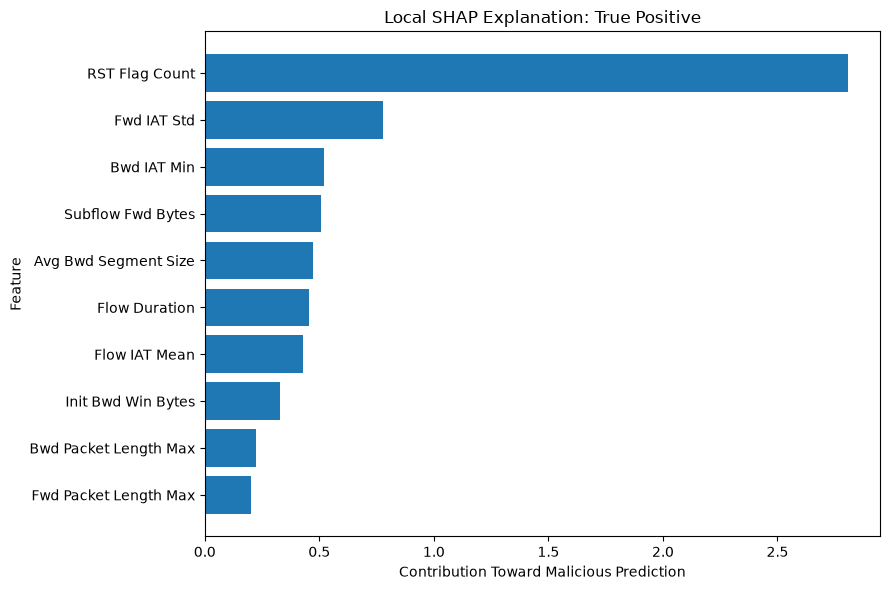

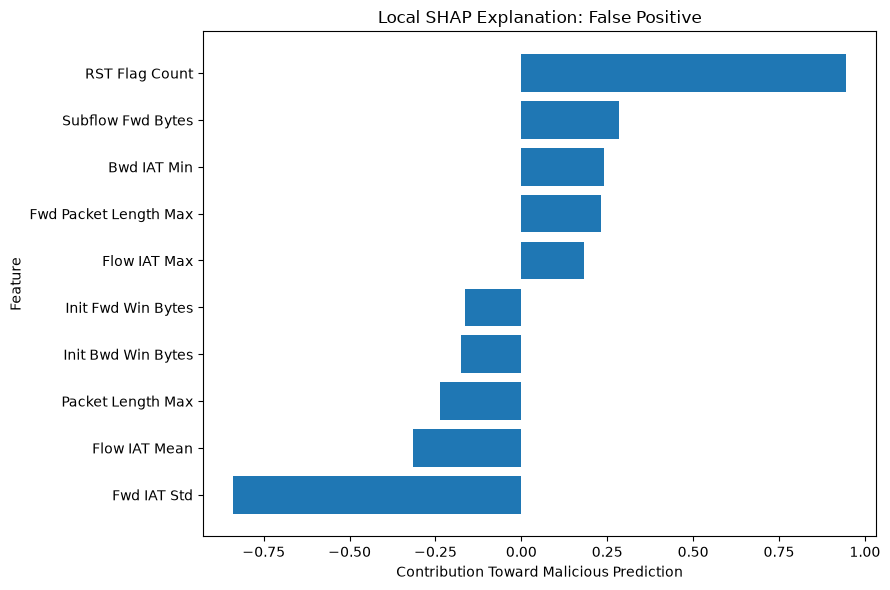

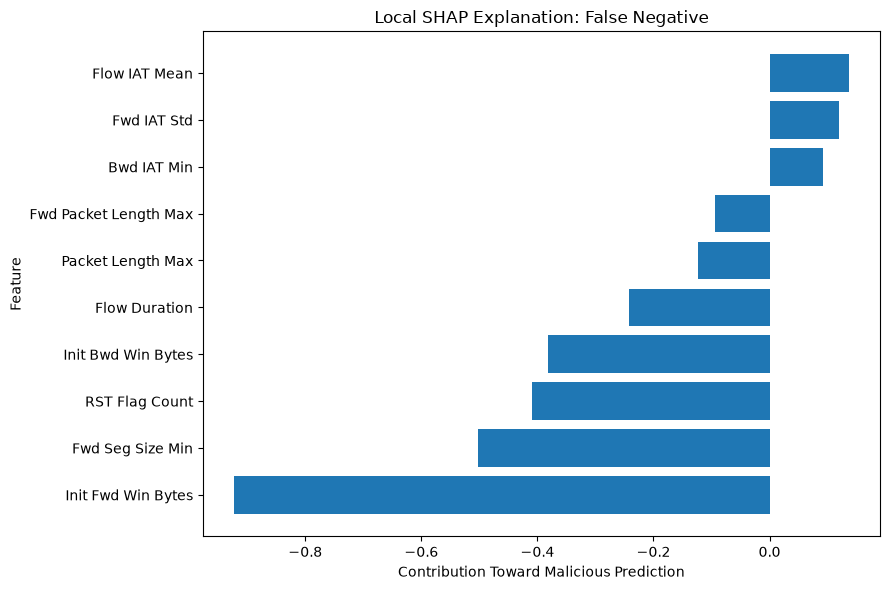

,prediction_result,feature,feature_value,shap_contribution,absolute_shap_contribution,actual_label,predicted_label,malicious_probability,original_attack_label
0,True Positive,RST Flag Count,1.000000e+00,2.807172,2.807172,1,1,0.999383,Bot
1,True Positive,Fwd IAT Std,5.628570e+02,0.779974,0.779974,1,1,0.999383,Bot
2,True Positive,Bwd IAT Min,7.200000e+01,0.521805,0.521805,1,1,0.999383,Bot
3,True Positive,Subflow Fwd Bytes,3.260000e+02,0.505441,0.505441,1,1,0.999383,Bot
4,True Positive,Avg Bwd Segment Size,3.225000e+01,0.472014,0.472014,1,1,0.999383,Bot
5,True Positive,Flow Duration,1.090700e+04,0.456167,0.456167,1,1,0.999383,Bot
6,True Positive,Flow IAT Mean,1.817833e+03,0.429475,0.429475,1,1,0.999383,Bot
7,True Positive,Init Bwd Win Bytes,2.190000e+02,0.329782,0.329782,1,1,0.999383,Bot
8,True Positive,Bwd Packet Length Max,1.120000e+02,0.222990,0.222990,1,1,0.999383,Bot
9,True Positive,Fwd Packet Length Max,3.260000e+02,0.202072,0.202072,1,1,0.999383,Bot


Local explanations saved.


In [16]:
if SHAP_COMPLETED:
    local_explanation_records = []

    for result_type in [
        "True Positive",
        "False Positive",
        "False Negative"
    ]:
        matching_rows = shap_sample[
            shap_sample["prediction_result"]
            == result_type
        ]

        if matching_rows.empty:
            continue

        row_index = matching_rows.index[0]

        local_feature_values = (
            X_shap.loc[row_index]
        )

        local_shap_values = (
            shap_values_positive[
                row_index
            ]
        )

        local_table = pd.DataFrame({
            "prediction_result":
                result_type,
            "feature":
                selected_features,
            "feature_value":
                local_feature_values.values,
            "shap_contribution":
                local_shap_values,
            "absolute_shap_contribution":
                np.abs(
                    local_shap_values
                ),
            "actual_label":
                int(
                    shap_sample.loc[
                        row_index,
                        "binary_label"
                    ]
                ),
            "predicted_label":
                int(
                    shap_sample.loc[
                        row_index,
                        "predicted_label"
                    ]
                ),
            "malicious_probability":
                float(
                    shap_sample.loc[
                        row_index,
                        "malicious_probability"
                    ]
                ),
            "original_attack_label":
                str(
                    shap_sample.loc[
                        row_index,
                        "original_attack_label"
                    ]
                )
        })

        local_table = (
            local_table
            .sort_values(
                "absolute_shap_contribution",
                ascending=False
            )
            .head(10)
        )

        local_explanation_records.append(
            local_table
        )

        plt.figure(figsize=(9, 6))

        plot_table = (
            local_table
            .sort_values(
                "shap_contribution"
            )
        )

        plt.barh(
            plot_table["feature"],
            plot_table[
                "shap_contribution"
            ]
        )

        plt.title(
            f"Local SHAP Explanation: "
            f"{result_type}"
        )

        plt.xlabel(
            "Contribution Toward "
            "Malicious Prediction"
        )

        plt.ylabel("Feature")
        plt.tight_layout()

        safe_result_name = (
            result_type
            .lower()
            .replace(" ", "_")
        )

        plt.savefig(
            FIGURES_DIR
            / (
                "local_shap_"
                f"{safe_result_name}.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

    if local_explanation_records:
        local_explanations = pd.concat(
            local_explanation_records,
            ignore_index=True
        )

        display(local_explanations)

        local_explanations.to_csv(
            TABLES_DIR
            / "final_model_local_shap_examples.csv",
            index=False
        )

        print(
            "Local explanations saved."
        )

else:
    print(
        "Local SHAP explanations skipped."
    )

In [17]:
if misclassification_path.exists():
    final_errors = pd.read_parquet(
        misclassification_path
    )

    final_errors["error_type"] = np.where(
        final_errors["actual_label"] == 1,
        "False Negative",
        "False Positive"
    )

    final_errors["prediction_confidence"] = np.where(
        final_errors["predicted_label"] == 1,
        final_errors[
            "malicious_probability"
        ],
        1
        - final_errors[
            "malicious_probability"
        ]
    )

    confidence_bins = [
        0.50,
        0.60,
        0.70,
        0.80,
        0.90,
        1.000001
    ]

    confidence_labels = [
        "50–59%",
        "60–69%",
        "70–79%",
        "80–89%",
        "90–100%"
    ]

    final_errors[
        "confidence_band"
    ] = pd.cut(
        final_errors[
            "prediction_confidence"
        ],
        bins=confidence_bins,
        labels=confidence_labels,
        right=False
    )

    error_by_attack = (
        final_errors
        .groupby(
            [
                "original_attack_label",
                "error_type"
            ],
            as_index=False
        )
        .agg(
            error_count=(
                "source_row_id",
                "size"
            ),
            mean_malicious_probability=(
                "malicious_probability",
                "mean"
            ),
            mean_prediction_confidence=(
                "prediction_confidence",
                "mean"
            )
        )
    )

    error_by_confidence = (
        final_errors
        .groupby(
            [
                "error_type",
                "confidence_band"
            ],
            observed=False,
            as_index=False
        )
        .agg(
            error_count=(
                "source_row_id",
                "size"
            )
        )
    )

    display(error_by_attack)
    display(error_by_confidence)

    error_by_attack.to_csv(
        TABLES_DIR
        / "final_errors_by_attack_label.csv",
        index=False
    )

    error_by_confidence.to_csv(
        TABLES_DIR
        / "final_errors_by_confidence_band.csv",
        index=False
    )

    print(
        "Total final test errors:",
        f"{len(final_errors):,}"
    )

else:
    final_errors = pd.DataFrame()

    print(
        "Misclassification file was not found."
    )

,original_attack_label,error_type,error_count,mean_malicious_probability,mean_prediction_confidence
0,Benign,False Positive,5202,0.617387,0.617387
1,Bot,False Negative,161,0.282769,0.717231
2,Brute Force -Web,False Negative,46,0.190435,0.809565
3,Brute Force -XSS,False Negative,1,0.127204,0.872796
4,DDoS attacks-LOIC-HTTP,False Negative,2,0.471862,0.528138
5,DoS attacks-GoldenEye,False Negative,1,0.213446,0.786554
6,DoS attacks-Slowloris,False Negative,13,0.303827,0.696173
7,Infilteration,False Negative,21161,0.199684,0.800316
8,SQL Injection,False Negative,1,0.390512,0.609488


,error_type,confidence_band,error_count
0,False Negative,50–59%,1045
1,False Negative,60–69%,3671
2,False Negative,70–79%,4203
3,False Negative,80–89%,8336
4,False Negative,90–100%,4131
5,False Positive,50–59%,2892
6,False Positive,60–69%,1153
7,False Positive,70–79%,772
8,False Positive,80–89%,332
9,False Positive,90–100%,53


Total final test errors: 26,588


In [18]:
combined_feature_importance = (
    native_importance
    .merge(
        permutation_importance_table,
        on="feature",
        how="outer"
    )
)

if SHAP_COMPLETED:
    combined_feature_importance = (
        combined_feature_importance
        .merge(
            shap_importance,
            on="feature",
            how="outer"
        )
    )

combined_feature_importance[
    "native_importance_normalised"
] = (
    combined_feature_importance[
        "native_importance"
    ]
    / combined_feature_importance[
        "native_importance"
    ].sum()
)

permutation_total = (
    combined_feature_importance[
        "permutation_importance_mean"
    ].clip(lower=0).sum()
)

if permutation_total > 0:
    combined_feature_importance[
        "permutation_importance_normalised"
    ] = (
        combined_feature_importance[
            "permutation_importance_mean"
        ].clip(lower=0)
        / permutation_total
    )
else:
    combined_feature_importance[
        "permutation_importance_normalised"
    ] = 0

if SHAP_COMPLETED:
    combined_feature_importance[
        "shap_importance_normalised"
    ] = (
        combined_feature_importance[
            "mean_absolute_shap"
        ]
        / combined_feature_importance[
            "mean_absolute_shap"
        ].sum()
    )

    combined_feature_importance[
        "combined_rank"
    ] = combined_feature_importance[
        [
            "native_rank",
            "permutation_rank",
            "shap_rank"
        ]
    ].mean(axis=1)

else:
    combined_feature_importance[
        "combined_rank"
    ] = combined_feature_importance[
        [
            "native_rank",
            "permutation_rank"
        ]
    ].mean(axis=1)

combined_feature_importance = (
    combined_feature_importance
    .sort_values(
        "combined_rank"
    )
    .reset_index(drop=True)
)

display(combined_feature_importance)

combined_feature_importance.to_csv(
    TABLES_DIR
    / "final_combined_feature_importance.csv",
    index=False
)

,feature,native_importance,native_rank,permutation_importance_mean,permutation_importance_std,permutation_rank,mean_absolute_shap,shap_rank,native_importance_normalised,permutation_importance_normalised,shap_importance_normalised,combined_rank
0,Fwd Seg Size Min,0.160091,1,0.090589,0.004052,1,1.012419,1,0.160091,0.468220,0.155460,1.000000
1,RST Flag Count,0.105046,3,0.010369,0.000506,3,0.805806,3,0.105046,0.053594,0.123734,3.000000
2,Init Fwd Win Bytes,0.067227,6,0.071265,0.000465,2,0.881910,2,0.067227,0.368338,0.135420,3.333333
3,Bwd IAT Min,0.154985,2,0.002431,0.000068,6,0.523099,4,0.154985,0.012565,0.080324,4.000000
4,Fwd IAT Std,0.071886,5,0.001983,0.000130,7,0.337884,7,0.071886,0.010251,0.051883,6.333333
5,Init Bwd Win Bytes,0.052863,9,0.002863,0.000369,5,0.398537,6,0.052863,0.014800,0.061197,6.666667
6,Flow Duration,0.095989,4,0.001858,0.000402,8,0.292877,8,0.095989,0.009604,0.044972,6.666667
7,Fwd Packet Length Max,0.019394,14,0.006752,0.000152,4,0.503282,5,0.019394,0.034897,0.077281,7.666667
8,Bwd Packet Length Std,0.059036,7,0.000245,0.000346,14,0.244808,9,0.059036,0.001267,0.037591,10.000000
9,Packet Length Max,0.053594,8,0.000569,0.000501,13,0.200756,12,0.053594,0.002942,0.030827,11.000000


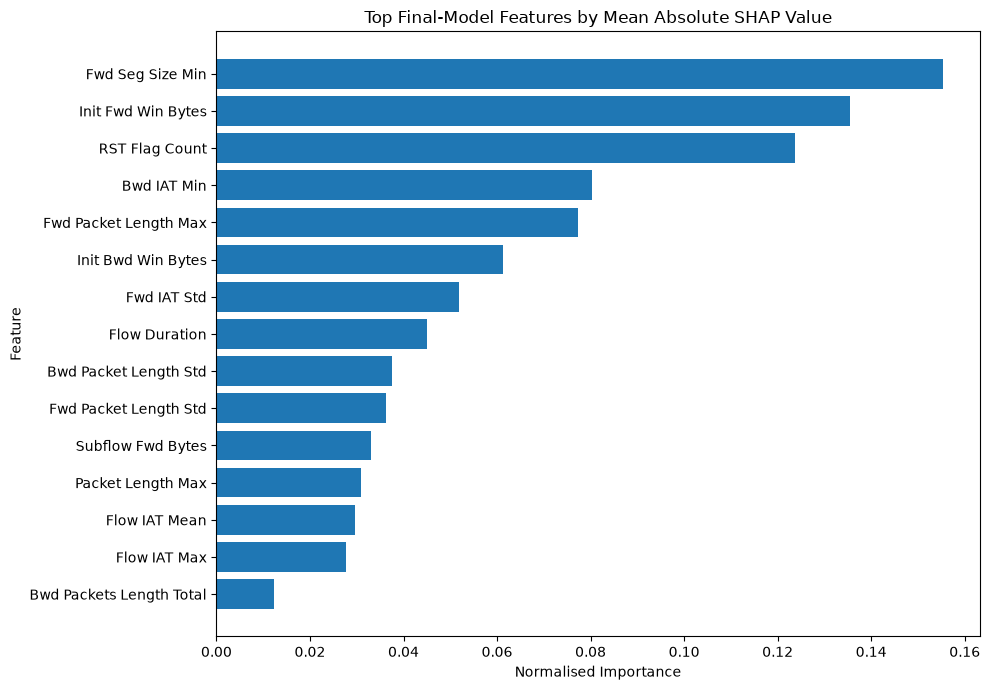

Feature-importance figure saved to: D:\Sami Data Set\outputs\figures\final_combined_feature_importance.png


In [19]:
top_importance_features = (
    combined_feature_importance
    .head(15)
    .copy()
)

if SHAP_COMPLETED:
    importance_column = (
        "shap_importance_normalised"
    )

    figure_title = (
        "Top Final-Model Features "
        "by Mean Absolute SHAP Value"
    )

else:
    importance_column = (
        "native_importance_normalised"
    )

    figure_title = (
        "Top Final-Model Features "
        "by Native Importance"
    )

top_importance_features = (
    top_importance_features
    .sort_values(
        importance_column,
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_importance_features[
        "feature"
    ],
    top_importance_features[
        importance_column
    ]
)

plt.title(figure_title)
plt.xlabel("Normalised Importance")
plt.ylabel("Feature")
plt.tight_layout()

importance_figure_path = (
    FIGURES_DIR
    / "final_combined_feature_importance.png"
)

plt.savefig(
    importance_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(
    "Feature-importance figure saved to:",
    importance_figure_path
)

In [20]:
final_result_row = final_results.iloc[0]

powerbi_model_summary = final_results.copy()

powerbi_metrics_long = pd.DataFrame([
    {
        "metric": "Accuracy",
        "value":
            final_result_row["accuracy"]
    },
    {
        "metric": "Malicious Precision",
        "value":
            final_result_row[
                "malicious_precision"
            ]
    },
    {
        "metric": "Malicious Recall",
        "value":
            final_result_row[
                "malicious_recall"
            ]
    },
    {
        "metric": "Malicious F1-score",
        "value":
            final_result_row[
                "malicious_f1"
            ]
    },
    {
        "metric": "ROC-AUC",
        "value":
            final_result_row["roc_auc"]
    },
    {
        "metric": "Average Precision",
        "value":
            final_result_row[
                "average_precision"
            ]
    }
])

powerbi_confusion_matrix = pd.DataFrame([
    {
        "actual_class": "Benign",
        "predicted_class": "Benign",
        "classification_result":
            "True Negative",
        "count": int(
            final_result_row[
                "true_negatives"
            ]
        )
    },
    {
        "actual_class": "Benign",
        "predicted_class": "Malicious",
        "classification_result":
            "False Positive",
        "count": int(
            final_result_row[
                "false_positives"
            ]
        )
    },
    {
        "actual_class": "Malicious",
        "predicted_class": "Benign",
        "classification_result":
            "False Negative",
        "count": int(
            final_result_row[
                "false_negatives"
            ]
        )
    },
    {
        "actual_class": "Malicious",
        "predicted_class": "Malicious",
        "classification_result":
            "True Positive",
        "count": int(
            final_result_row[
                "true_positives"
            ]
        )
    }
])

powerbi_model_summary.to_csv(
    POWERBI_DIR / "model_summary.csv",
    index=False
)

powerbi_metrics_long.to_csv(
    POWERBI_DIR / "model_metrics.csv",
    index=False
)

powerbi_confusion_matrix.to_csv(
    POWERBI_DIR / "confusion_matrix.csv",
    index=False
)

file_results.to_csv(
    POWERBI_DIR / "performance_by_test_file.csv",
    index=False
)

attack_results.to_csv(
    POWERBI_DIR / "performance_by_attack_label.csv",
    index=False
)

combined_feature_importance.to_csv(
    POWERBI_DIR / "feature_importance.csv",
    index=False
)

if misclassification_path.exists():
    error_by_attack.to_csv(
        POWERBI_DIR
        / "errors_by_attack_label.csv",
        index=False
    )

    error_by_confidence.to_csv(
        POWERBI_DIR
        / "errors_by_confidence_band.csv",
        index=False
    )

print("Power BI datasets created:")

for powerbi_file in sorted(
    POWERBI_DIR.glob("*.csv")
):
    print("-", powerbi_file.name)

Power BI datasets created:
- confusion_matrix.csv
- errors_by_attack_label.csv
- errors_by_confidence_band.csv
- feature_importance.csv
- model_metrics.csv
- model_summary.csv
- performance_by_attack_label.csv
- performance_by_test_file.csv


In [21]:
powerbi_data_dictionary = pd.DataFrame([
    {
        "file_name": "model_summary.csv",
        "purpose":
            "One-row summary of final model performance",
        "recommended_visual":
            "Summary cards"
    },
    {
        "file_name": "model_metrics.csv",
        "purpose":
            "Final evaluation metrics in long format",
        "recommended_visual":
            "Cards or clustered column chart"
    },
    {
        "file_name": "confusion_matrix.csv",
        "purpose":
            "True-positive, true-negative and error counts",
        "recommended_visual":
            "Matrix or stacked column chart"
    },
    {
        "file_name":
            "performance_by_test_file.csv",
        "purpose":
            "Performance variation across source test files",
        "recommended_visual":
            "Table and line or column chart"
    },
    {
        "file_name":
            "performance_by_attack_label.csv",
        "purpose":
            "Detection rates for individual attack categories",
        "recommended_visual":
            "Horizontal bar chart"
    },
    {
        "file_name": "feature_importance.csv",
        "purpose":
            "Native, permutation and SHAP importance",
        "recommended_visual":
            "Ranked horizontal bar chart"
    },
    {
        "file_name":
            "errors_by_attack_label.csv",
        "purpose":
            "False-positive and false-negative distribution",
        "recommended_visual":
            "Stacked bar chart"
    },
    {
        "file_name":
            "errors_by_confidence_band.csv",
        "purpose":
            "Model errors grouped by prediction confidence",
        "recommended_visual":
            "Stacked column chart"
    }
])

display(powerbi_data_dictionary)

powerbi_data_dictionary.to_csv(
    POWERBI_DIR
    / "powerbi_data_dictionary.csv",
    index=False
)


,file_name,purpose,recommended_visual
0,model_summary.csv,One-row summary of final model performance,Summary cards
1,model_metrics.csv,Final evaluation metrics in long format,Cards or clustered column chart
2,confusion_matrix.csv,"True-positive, true-negative and error counts",Matrix or stacked column chart
3,performance_by_test_file.csv,Performance variation across source test files,Table and line or column chart
4,performance_by_attack_label.csv,Detection rates for individual attack categories,Horizontal bar chart
5,feature_importance.csv,"Native, permutation and SHAP importance",Ranked horizontal bar chart
6,errors_by_attack_label.csv,False-positive and false-negative distribution,Stacked bar chart
7,errors_by_confidence_band.csv,Model errors grouped by prediction confidence,Stacked column chart


In [22]:
explainability_information = {
    "final_algorithm":
        final_algorithm,
    "selected_feature_count":
        len(selected_features),
    "explanation_sample_records":
        len(explanation_sample),
    "permutation_sample_records":
        PERMUTATION_SAMPLE_SIZE,
    "permutation_repeats":
        3,
    "shap_completed":
        SHAP_COMPLETED,
    "shap_sample_records":
        len(X_shap),
    "explanation_purpose":
        (
            "Post-test interpretation and error "
            "analysis only"
        ),
    "model_changes_after_test":
        False,
    "threshold_changes_after_test":
        False,
    "powerbi_output_directory":
        str(POWERBI_DIR)
}

with open(
    DOCUMENTATION_DIR
    / "explainability_analysis.json",
    "w",
    encoding="utf-8"
) as explainability_file:
    json.dump(
        explainability_information,
        explainability_file,
        indent=4
    )

print(
    "Explainability documentation saved."
)

Explainability documentation saved.


## Explainability and Error-Analysis Conclusion

The final model was interpreted using native feature importance,
permutation importance and SHAP values. These techniques were applied
after final test evaluation and were used only to explain model
behaviour; no model, feature or threshold changes were made.

Global explanations identified the network-flow variables that
contributed most strongly to the final predictions. Local SHAP
examples were generated for correct malicious detections, false
positives and false negatives where suitable examples were available.
Positive SHAP contributions pushed predictions toward the malicious
class, while negative contributions pushed predictions toward the
benign class.

Error analysis was conducted across original attack labels and
prediction-confidence bands. This identified attack categories with
strong detection performance and categories associated with
false-negative errors. Results for very rare attack labels require
cautious interpretation because their percentages are based on small
record counts.

Aggregated model metrics, confusion-matrix counts, attack-level
performance, feature importance and error summaries were exported as
CSV files for Power BI dashboard development.

In [23]:
from pathlib import Path
import pyarrow.parquet as pq
import pandas as pd

PROJECT_DIR = Path(r"D:\Sami Data Set")

TRAIN_DIR = PROJECT_DIR / "data" / "splits" / "train"
TEST_DIR = PROJECT_DIR / "data" / "splits" / "test"

train_files = sorted(TRAIN_DIR.glob("*_train.parquet"))
test_files = sorted(TEST_DIR.glob("*_test.parquet"))

train_records = sum(
    pq.ParquetFile(file).metadata.num_rows
    for file in train_files
)

test_records = sum(
    pq.ParquetFile(file).metadata.num_rows
    for file in test_files
)

total_records = train_records + test_records

summary = pd.DataFrame([
    {
        "Dataset": "Training",
        "Files": len(train_files),
        "Records": train_records,
        "Percentage": train_records / total_records * 100
    },
    {
        "Dataset": "Testing",
        "Files": len(test_files),
        "Records": test_records,
        "Percentage": test_records / total_records * 100
    }
])

display(summary)

print("Total records:", f"{total_records:,}")

,Dataset,Files,Records,Percentage
0,Training,10,5327625,79.999991
1,Testing,10,1331907,20.000009


Total records: 6,659,532


In [24]:
def count_classes(files):
    benign = 0
    malicious = 0

    for file in files:
        labels = pd.read_parquet(
            file,
            columns=["binary_label"]
        )["binary_label"]

        benign += int((labels == 0).sum())
        malicious += int((labels == 1).sum())

    return benign, malicious


train_benign, train_malicious = count_classes(train_files)
test_benign, test_malicious = count_classes(test_files)

class_summary = pd.DataFrame([
    {
        "Dataset": "Training",
        "Benign": train_benign,
        "Malicious": train_malicious,
        "Total": train_benign + train_malicious
    },
    {
        "Dataset": "Testing",
        "Benign": test_benign,
        "Malicious": test_malicious,
        "Total": test_benign + test_malicious
    }
])

display(class_summary)

,Dataset,Benign,Malicious,Total
0,Training,4263206,1064419,5327625
1,Testing,1065802,266105,1331907
